In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Hours_Studied": [1,2,3,4,5,6,7,8,2,3,5,6,1,4,7],
    "Sleep_Hours": [7,6,6,5,5,4,4,3,7,6,5,4,8,5,3],
    "Score": [35,40,50,55,65,70,75,85,45,48,68,72,30,60,80]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Sleep_Hours,Score
0,1,7,35
1,2,6,40
2,3,6,50
3,4,5,55
4,5,5,65
5,6,4,70
6,7,4,75
7,8,3,85
8,2,7,45
9,3,6,48


In [4]:
df.to_csv("dataset.csv", index=False)

In [5]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Hours_Studied  Sleep_Hours  Score
0              1            7     35
1              2            6     40
2              3            6     50
3              4            5     55
4              5            5     65
    Hours_Studied  Sleep_Hours  Score
10              5            5     68
11              6            4     72
12              1            8     30
13              4            5     60
14              7            3     80
(15, 3)
Hours_Studied    int64
Sleep_Hours      int64
Score            int64
dtype: object
Hours_Studied    0
Sleep_Hours      0
Score            0
dtype: int64


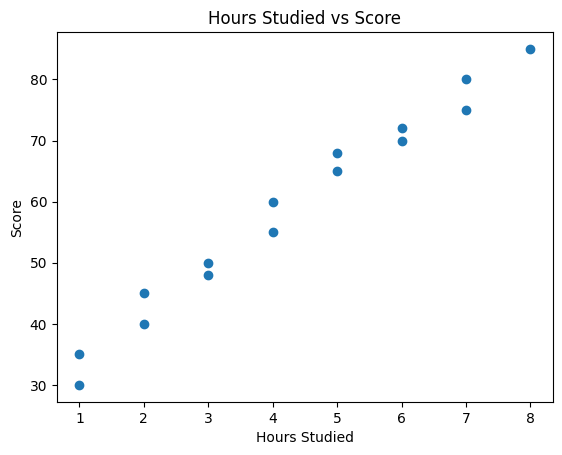

In [7]:
plt.scatter(df["Hours_Studied"], df["Score"])
plt.title("Hours Studied vs Score")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()

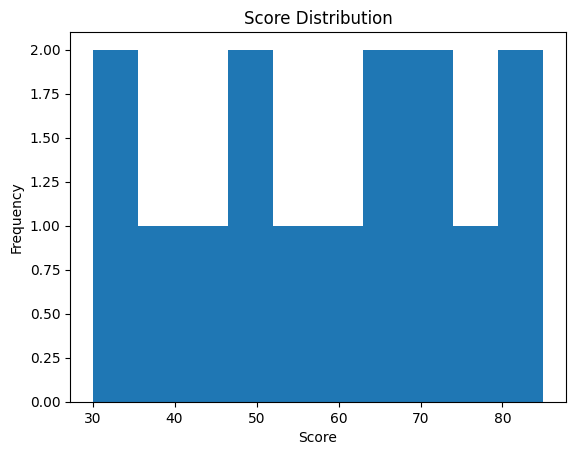

In [8]:
plt.hist(df["Score"])
plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

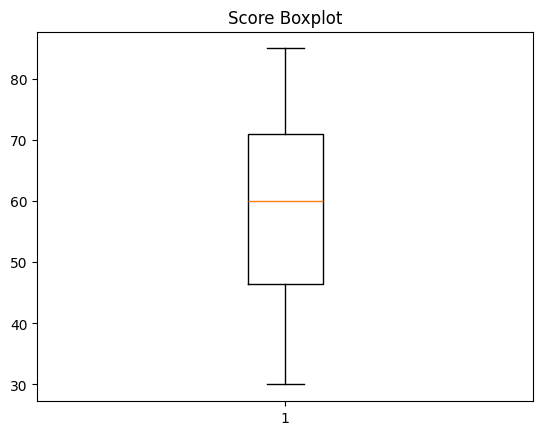

In [9]:
plt.boxplot(df["Score"])
plt.title("Score Boxplot")
plt.show()

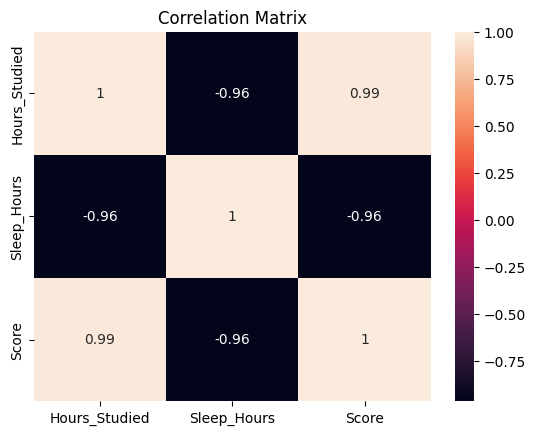

In [10]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["Hours_Studied", "Sleep_Hours"]]
y = df["Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.6210287443267788
R2: 0.9974511468451903


The MAE shows the average error between predicted and actual scores.
The R2 score indicates how well the model explains the data.
The model performs well and shows that study hours strongly influence scores.

In [12]:
X1 = df[["Hours_Studied"]]

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

print("R2 without Sleep:", r2_score(y_test, model1.predict(X_test)))

R2 without Sleep: 0.9969111472513038


In [13]:
df["Total_Effort"] = df["Hours_Studied"] * df["Sleep_Hours"]

X2 = df[["Hours_Studied", "Sleep_Hours", "Total_Effort"]]

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)

print("R2 with new feature:", r2_score(y_test, model2.predict(X_test)))

R2 with new feature: 0.9905833861433369


Removing sleep reduced performance.
Adding Total_Effort improved the model.
Hours studied is the most important feature.

In [14]:
model_full = LinearRegression()
model_full.fit(X, y)

print("R2 on full data:", r2_score(y, model_full.predict(X)))

R2 on full data: 0.9794858476759863


Training on full data gives very high accuracy but is misleading.
This is called overfitting.
The model memorizes instead of learning patterns.
Train-test split gives better real-world performance.